In [1]:
import pandas as pd

df1 = pd.read_csv('Credit_Card_Dataset_2025_Sept_1.csv')
df2 = pd.read_csv('Credit_Card_Dataset_2025_Sept_2.csv')

In [2]:
print("Shape of Dataset 1:", df1.shape)
print("Columns in Dataset 1:", df1.columns.tolist())

print("\nShape of Dataset 2:", df2.shape)
print("Columns in Dataset 2:", df2.columns.tolist())

Shape of Dataset 1: (25134, 17)
Columns in Dataset 1: ['Unnamed: 0', 'ID', 'GENDER', 'CAR', 'REALITY', 'NO_OF_CHILD', 'FAMILY_TYPE', 'HOUSE_TYPE', 'FLAG_MOBIL', 'WORK_PHONE', 'PHONE', 'E_MAIL', 'FAMILY SIZE', 'BEGIN_MONTH', 'AGE', 'YEARS_EMPLOYED', 'TARGET']

Shape of Dataset 2: (25134, 4)
Columns in Dataset 2: ['INCOME', 'INCOME_TYPE', 'User', 'EDUCATION_TYPE']


In [3]:
# Check primary key in both files & identifying row count

print("Unique IDs in df1:", df1['ID'].nunique())
print("Unique IDs in df2:", df2['User'].nunique())

Unique IDs in df1: 25134
Unique IDs in df2: 25134


In [4]:
merged_df = pd.merge(df1, df2, left_on='ID', right_on='User', how='inner')
if 'User' in merged_df.columns and 'ID' in merged_df.columns:
    merged_df = merged_df.drop(columns=['User'])

print("=== MERGED DATASET ===")
print("Shape after merge:", merged_df.shape)
print("Total rows should be close to 25,134 →", merged_df.shape[0])

=== MERGED DATASET ===
Shape after merge: (25134, 20)
Total rows should be close to 25,134 → 25134


In [5]:
# Check for any duplicate IDs after merge (should be zero)

print("Duplicate IDs:", merged_df['ID'].duplicated().sum())

Duplicate IDs: 0


In [6]:
# Save the merged file

merged_df.to_csv('Merged_Credit_Card_Dataset_2025.csv', index=False)

In [7]:
print("First 5 rows of merged dataset:")
print(merged_df.head())

First 5 rows of merged dataset:
   Unnamed: 0       ID GENDER CAR REALITY  NO_OF_CHILD           FAMILY_TYPE  \
0           0  5008806      M   Y       Y            0               Married   
1           1  5008808      F   N       Y            0  Single / not married   
2           2  5008809      F   N       Y            0  Single / not married   
3           3  5008810      F   N       Y            0  Single / not married   
4           4  5008811      F   N       Y            0  Single / not married   

          HOUSE_TYPE  FLAG_MOBIL  WORK_PHONE  PHONE  E_MAIL  FAMILY SIZE  \
0  House / apartment           1           0      0       0          2.0   
1  House / apartment           1           0      1       1          1.0   
2  House / apartment           1           0      1       1          1.0   
3  House / apartment           1           0      1       1          1.0   
4  House / apartment           1           0      1       1          1.0   

   BEGIN_MONTH  AGE  YEARS_EMP

In [8]:
# Check missing values

print(merged_df.isnull().sum())

Unnamed: 0         0
ID                 0
GENDER             0
CAR                0
REALITY            0
NO_OF_CHILD        0
FAMILY_TYPE        0
HOUSE_TYPE         0
FLAG_MOBIL         0
WORK_PHONE         0
PHONE              0
E_MAIL             0
FAMILY SIZE        1
BEGIN_MONTH        0
AGE                0
YEARS_EMPLOYED     9
TARGET             0
INCOME             0
INCOME_TYPE       12
EDUCATION_TYPE     0
dtype: int64


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
%matplotlib inline

In [10]:
df = pd.read_csv('Merged_Credit_Card_Dataset_2025.csv')

In [11]:
# Fundamental data understanding - Shape and basic info

print("=== 1. Dataset Shape ===")
print(f"Number of rows (observations): {df.shape[0]:,}")
print(f"Number of columns (features): {df.shape[1]}")

print("\n=== 2. Column Names ===")
print(df.columns.tolist())

print("\n=== 3. Data Types ===")
print(df.dtypes)


=== 1. Dataset Shape ===
Number of rows (observations): 25,134
Number of columns (features): 20

=== 2. Column Names ===
['Unnamed: 0', 'ID', 'GENDER', 'CAR', 'REALITY', 'NO_OF_CHILD', 'FAMILY_TYPE', 'HOUSE_TYPE', 'FLAG_MOBIL', 'WORK_PHONE', 'PHONE', 'E_MAIL', 'FAMILY SIZE', 'BEGIN_MONTH', 'AGE', 'YEARS_EMPLOYED', 'TARGET', 'INCOME', 'INCOME_TYPE', 'EDUCATION_TYPE']

=== 3. Data Types ===
Unnamed: 0          int64
ID                  int64
GENDER             object
CAR                object
REALITY            object
NO_OF_CHILD         int64
FAMILY_TYPE        object
HOUSE_TYPE         object
FLAG_MOBIL          int64
WORK_PHONE          int64
PHONE               int64
E_MAIL              int64
FAMILY SIZE       float64
BEGIN_MONTH         int64
AGE                 int64
YEARS_EMPLOYED    float64
TARGET              int64
INCOME            float64
INCOME_TYPE        object
EDUCATION_TYPE     object
dtype: object


=== Missing Values Analysis ===
                Missing Count  Missing Percentage (%)
INCOME_TYPE                12                0.047744
YEARS_EMPLOYED              9                0.035808
FAMILY SIZE                 1                0.003979


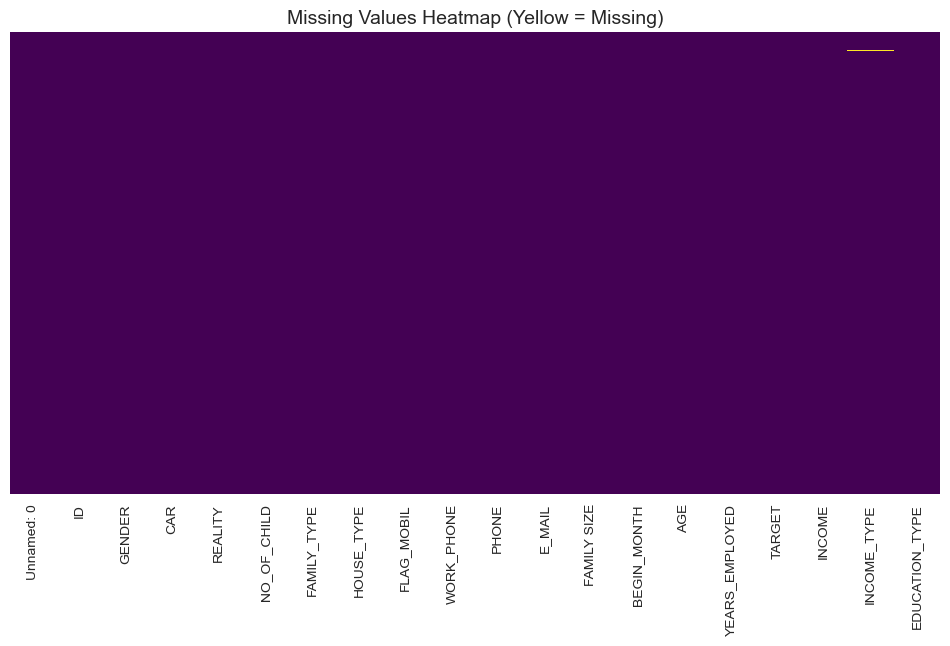

In [12]:
# Missing values analysis

print("=== Missing Values Analysis ===")
missing = pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Missing Percentage (%)': (df.isnull().sum() / len(df)) * 100
}).sort_values(by='Missing Count', ascending=False)

print(missing[missing['Missing Count'] > 0])

# Visualise missing values

plt.figure(figsize=(12, 6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis', yticklabels=False)
plt.title('Missing Values Heatmap (Yellow = Missing)', fontsize=14)
plt.show()


=== Target Variable Distribution ===
TARGET
0    24712
1      422
Name: count, dtype: int64

Target imbalance ratio (0:1): 58.56:1


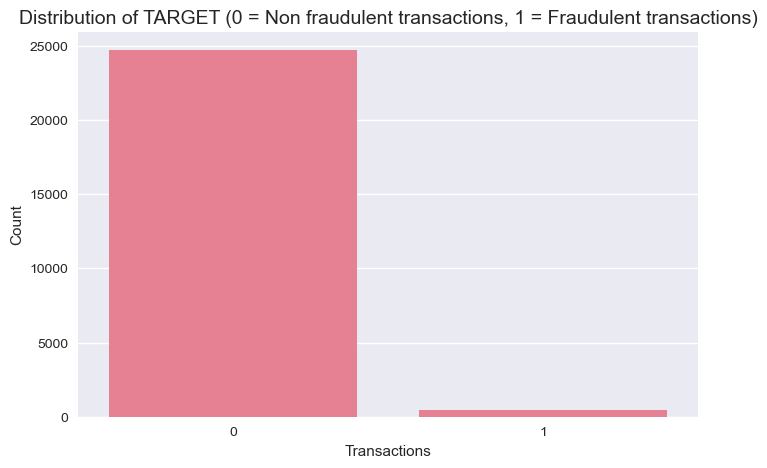

In [13]:
# Target variable analysis

print("=== Target Variable Distribution ===")
print(df['TARGET'].value_counts())
print(f"\nTarget imbalance ratio (0:1): {df['TARGET'].value_counts()[0] / df['TARGET'].value_counts().get(1, 1):.2f}:1")

# Visualisation

plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='TARGET')
plt.title('Distribution of TARGET (0 = Non fraudulent transactions, 1 = Fraudulent transactions)', fontsize=14)
plt.xlabel('Transactions')
plt.ylabel('Count')
plt.show()

Numerical columns (13): ['Unnamed: 0', 'ID', 'NO_OF_CHILD', 'FLAG_MOBIL', 'WORK_PHONE', 'PHONE', 'E_MAIL', 'FAMILY SIZE', 'BEGIN_MONTH', 'AGE', 'YEARS_EMPLOYED', 'TARGET', 'INCOME']

=== Numerical Features Summary ===


,Unnamed: 0,ID,NO_OF_CHILD,FLAG_MOBIL,WORK_PHONE,PHONE,E_MAIL,FAMILY SIZE,BEGIN_MONTH,AGE,YEARS_EMPLOYED,TARGET,INCOME
count,25134.00,25134.00,25134.00,25134.0,25134.00,25134.00,25134.0,25133.00,25134.00,25134.00,25125.00,25134.00,25134.00
mean,12566.50,5078837.56,0.51,1.0,0.27,0.29,0.1,2.29,26.12,40.59,7.21,0.02,194833.85
std,7255.71,41941.02,0.79,0.0,0.45,0.46,0.3,0.95,16.44,10.35,6.42,0.13,104510.99
min,0.00,5008806.00,0.00,1.0,0.00,0.00,0.0,1.00,0.00,21.00,0.00,0.00,27000.00
25%,6283.25,5042228.25,0.00,1.0,0.00,0.00,0.0,2.00,12.00,33.00,3.00,0.00,135000.00
50%,12566.50,5079004.00,0.00,1.0,0.00,0.00,0.0,2.00,24.00,40.00,5.00,0.00,180000.00
75%,18849.75,5115603.75,1.00,1.0,1.00,1.00,0.0,3.00,39.00,48.00,10.00,0.00,225000.00
max,25133.00,5150487.00,19.00,1.0,1.00,1.00,1.0,20.00,60.00,450.00,43.00,1.00,1575000.00


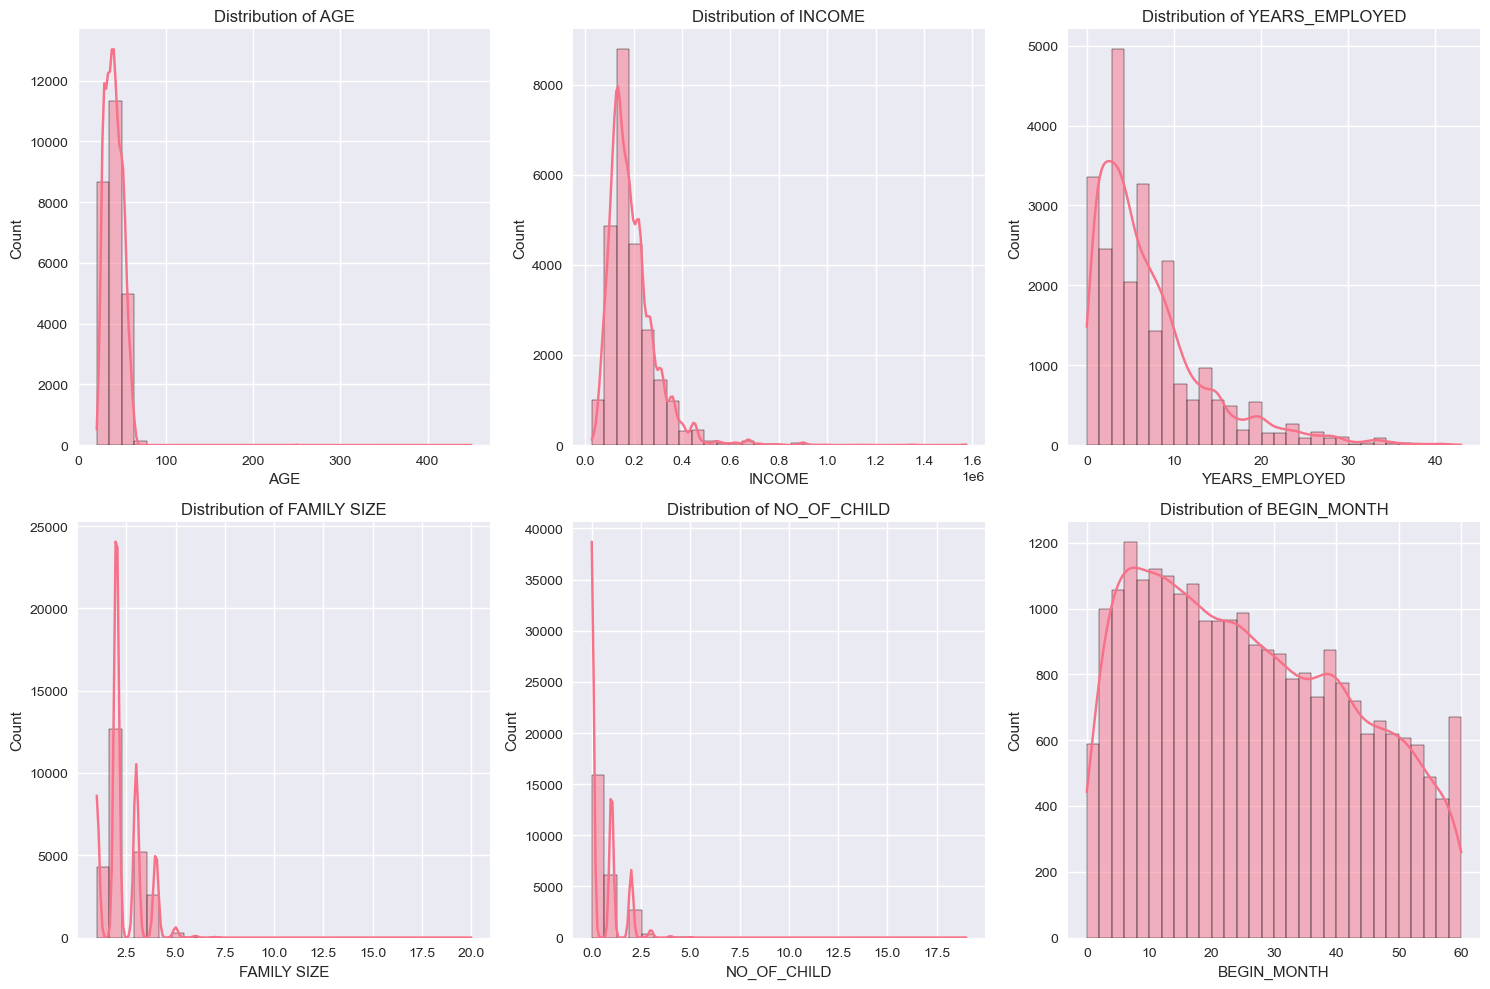

In [14]:
# Cell 7: Numerical features - Summary statistics & distribution
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()
print(f"Numerical columns ({len(numerical_cols)}): {numerical_cols}")

# Descriptive statistics
print("\n=== Numerical Features Summary ===")
display(df[numerical_cols].describe().round(2))

# Distribution plots for key numerical features (AGE, INCOME, YEARS_EMPLOYED, FAMILY SIZE)
key_num = ['AGE', 'INCOME', 'YEARS_EMPLOYED', 'FAMILY SIZE', 'NO_OF_CHILD', 'BEGIN_MONTH']

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()

for i, col in enumerate(key_num):
    if col in df.columns:
        sns.histplot(data=df, x=col, kde=True, ax=axes[i], bins=30)
        axes[i].set_title(f'Distribution of {col}')
        axes[i].set_xlabel(col)

plt.tight_layout()
plt.show()

In [15]:
# Cell 8: Categorical features analysis
categorical_cols = df.select_dtypes(include=['object', 'bool']).columns.tolist()
print(f"Categorical columns ({len(categorical_cols)}): {categorical_cols}")

# Value counts for important categorical features
important_cat = ['GENDER', 'CAR', 'REALITY', 'FAMILY_TYPE', 'HOUSE_TYPE', 'INCOME_TYPE', 'EDUCATION_TYPE']

for col in important_cat:
    if col in df.columns:
        print(f"\n=== {col} Distribution ===")
        print(df[col].value_counts(normalize=True).round(3) * 100)
        print("-" * 40)

Categorical columns (7): ['GENDER', 'CAR', 'REALITY', 'FAMILY_TYPE', 'HOUSE_TYPE', 'INCOME_TYPE', 'EDUCATION_TYPE']

=== GENDER Distribution ===
GENDER
F    62.2
M    37.8
Name: proportion, dtype: float64
----------------------------------------

=== CAR Distribution ===
CAR
N    58.2
Y    41.8
Name: proportion, dtype: float64
----------------------------------------

=== REALITY Distribution ===
REALITY
Y    65.5
N    34.5
Name: proportion, dtype: float64
----------------------------------------

=== FAMILY_TYPE Distribution ===
FAMILY_TYPE
Married                 69.7
Single / not married    13.7
Civil marriage           8.5
Separated                5.8
Widow                    2.3
Name: proportion, dtype: float64
----------------------------------------

=== HOUSE_TYPE Distribution ===
HOUSE_TYPE
House / apartment      87.9
With parents            5.7
Municipal apartment     3.2
Rented apartment        1.7
Office apartment        0.8
Co-op apartment         0.6
Name: proportion, dty

In [16]:
# Duplicate analysis 
print("=== Duplicate Analysis ===")
print(f"Exact duplicate rows: {df.duplicated().sum():,}")
print(f"Duplicate IDs (if ID exists): {df['ID'].duplicated().sum() if 'ID' in df.columns else 'No ID column'}")

# Check if multiple records per person
if 'ID' in df.columns and 'BEGIN_MONTH' in df.columns:
    print(f"\nRecords per ID (average): {df.groupby('ID').size().mean():.2f}")
    print("Most common number of records per ID:")
    print(df.groupby('ID').size().value_counts().head(10))

=== Duplicate Analysis ===
Exact duplicate rows: 0
Duplicate IDs (if ID exists): 0

Records per ID (average): 1.00
Most common number of records per ID:
1    25134
Name: count, dtype: int64


In [17]:
# useless columns
# Unnamed: 0 is just an index

df_clean = df.copy()  
columns_to_drop = ['Unnamed: 0']
df_clean = df_clean.drop(columns=columns_to_drop, errors='ignore')

print(f"Columns after drop: {df_clean.columns.tolist()}")
print(f"New shape: {df_clean.shape}")

Columns after drop: ['ID', 'GENDER', 'CAR', 'REALITY', 'NO_OF_CHILD', 'FAMILY_TYPE', 'HOUSE_TYPE', 'FLAG_MOBIL', 'WORK_PHONE', 'PHONE', 'E_MAIL', 'FAMILY SIZE', 'BEGIN_MONTH', 'AGE', 'YEARS_EMPLOYED', 'TARGET', 'INCOME', 'INCOME_TYPE', 'EDUCATION_TYPE']
New shape: (25134, 19)


In [18]:


# ========================
# 2. Now handle missing values
# ========================

print("Missing values BEFORE handling:")
print(df_clean.isnull().sum()[df_clean.isnull().sum() > 0])

# 1. FAMILY SIZE → median within same FAMILY_TYPE
df_clean['FAMILY SIZE'] = df_clean.groupby('FAMILY_TYPE', observed=True)['FAMILY SIZE'].transform(
    lambda x: x.fillna(x.median())
)

# 2. YEARS_EMPLOYED → 0 
df_clean['YEARS_EMPLOYED'] = df_clean['YEARS_EMPLOYED'].fillna(0)

# 3. EDUCATION_TYPE → most frequent value
df_clean['EDUCATION_TYPE'] = df_clean['EDUCATION_TYPE'].fillna(
    df_clean['EDUCATION_TYPE'].mode()[0]
)

# 4. Drop any remaining rows with NaNs
df_clean = df_clean.dropna()

print("\nMissing values AFTER handling:", df_clean.isnull().sum().sum())
print(f"Rows after missing-value treatment: {df_clean.shape[0]:,}")
print(f"Original rows: {df.shape[0]:,}")

Missing values BEFORE handling:
FAMILY SIZE        1
YEARS_EMPLOYED     9
INCOME_TYPE       12
dtype: int64

Missing values AFTER handling: 0
Rows after missing-value treatment: 25,122
Original rows: 25,134


In [19]:
# Fix Data Types & Clean Binary Flags

# Ensure numeric columns are proper
num_cols = ['FAMILY SIZE', 'BEGIN_MONTH', 'AGE', 'YEARS_EMPLOYED', 'INCOME', 'NO_OF_CHILD']
for col in num_cols:
    if col in df_clean.columns:
        df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')

# Binary flags
binary_flags = ['FLAG_MOBIL', 'WORK_PHONE', 'PHONE', 'E_MAIL']
for col in binary_flags:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].astype('Int64')

print("Data types fixed successfully.")

Data types fixed successfully.


In [20]:
# Remove Exact Duplicates

print(f"Exact duplicate rows before: {df_clean.duplicated().sum():,}")
df_clean = df_clean.drop_duplicates()
print(f"Exact duplicate rows after: {df_clean.duplicated().sum():,}")
print(f"Shape after duplicate removal: {df_clean.shape}")

Exact duplicate rows before: 0
Exact duplicate rows after: 0
Shape after duplicate removal: (25122, 19)


In [21]:
# Outlier Treatment

##### here outlier columns are manually define #########


def cap_outliers(series, lower=0.01, upper=0.99):
    return series.clip(lower=series.quantile(lower), upper=series.quantile(upper))

outlier_cols = ['INCOME', 'AGE', 'YEARS_EMPLOYED']
for col in outlier_cols:
    if col in df_clean.columns:
        df_clean[col] = cap_outliers(df_clean[col])
        print(f"→ {col} capped at 1% / 99% percentiles")

print("\nAfter capping:")
print(df_clean[outlier_cols].describe().round(2))

→ INCOME capped at 1% / 99% percentiles
→ AGE capped at 1% / 99% percentiles
→ YEARS_EMPLOYED capped at 1% / 99% percentiles

After capping:
          INCOME       AGE  YEARS_EMPLOYED
count   25122.00  25122.00        25122.00
mean   193094.42     40.53            7.16
std     93225.52      9.50            6.23
min     63000.00     24.00            0.00
25%    135000.00     33.00            3.00
50%    180000.00     40.00            5.00
75%    225000.00     48.00           10.00
max    585000.00     62.00           30.00


In [22]:
# Feature Engineering




# 1. Income per family member (strong repayment capacity signal)
df_clean['INCOME_PER_FAMILY_MEMBER'] = df_clean['INCOME'] / df_clean['FAMILY SIZE'].replace(0, 1)

# 2. Employment stability ratio
df_clean['EMPLOYMENT_TO_AGE_RATIO'] = df_clean['YEARS_EMPLOYED'] / df_clean['AGE'].replace(0, 1)

# 3. Has child flag
df_clean['HAS_CHILD'] = (df_clean['NO_OF_CHILD'] > 0).astype(int)

# 4. Age group (categorical bins perform better than raw age in many models)
df_clean['AGE_GROUP'] = pd.cut(df_clean['AGE'], 
                               bins=[0, 25, 35, 45, 55, 100], 
                               labels=['Young', 'Young_Adult', 'Middle_Age', 'Senior', 'Elderly'])

# 5. Single-person household flag
df_clean['IS_SINGLE'] = (df_clean['FAMILY SIZE'] == 1).astype(int)

# 6. Log income (handles right-skew common in income data)
df_clean['LOG_INCOME'] = np.log1p(df_clean['INCOME'])

print(f" 6 new features created. Final shape: {df_clean.shape}")

 6 new features created. Final shape: (25122, 25)


In [23]:
# Encode Binary Categorical Variables

binary_map = {'M': 1, 'F': 0, 'Y': 1, 'N': 0}
for col in ['GENDER', 'CAR', 'REALITY']:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].map(binary_map)

print("Binary features (GENDER, CAR, REALITY) encoded to 0/1.")

Binary features (GENDER, CAR, REALITY) encoded to 0/1.


In [24]:
# Check & Save 
print("PREPROCESSED DATASET")
print(f"Rows    : {df_clean.shape[0]:,}")
print(f"Columns : {df_clean.shape[1]}")
print("\nColumns ready for modeling:")
print(df_clean.columns.tolist())

# TARGET distribution
print("\nTARGET distribution (%):")
print(df_clean['TARGET'].value_counts(normalize=True).round(4) * 100)

# Save cleaned version
df_clean.to_csv('Preprocessed_Credit_Card_Dataset.csv', index=False)
print("\nPreprocessed dataset saved as 'Preprocessed_Credit_Card_Dataset.csv'")

PREPROCESSED DATASET
Rows    : 25,122
Columns : 25

Columns ready for modeling:
['ID', 'GENDER', 'CAR', 'REALITY', 'NO_OF_CHILD', 'FAMILY_TYPE', 'HOUSE_TYPE', 'FLAG_MOBIL', 'WORK_PHONE', 'PHONE', 'E_MAIL', 'FAMILY SIZE', 'BEGIN_MONTH', 'AGE', 'YEARS_EMPLOYED', 'TARGET', 'INCOME', 'INCOME_TYPE', 'EDUCATION_TYPE', 'INCOME_PER_FAMILY_MEMBER', 'EMPLOYMENT_TO_AGE_RATIO', 'HAS_CHILD', 'AGE_GROUP', 'IS_SINGLE', 'LOG_INCOME']

TARGET distribution (%):
TARGET
0    98.32
1     1.68
Name: proportion, dtype: float64

Preprocessed dataset saved as 'Preprocessed_Credit_Card_Dataset.csv'


In [25]:
df = pd.read_csv('Preprocessed_Credit_Card_Dataset.csv')

print(f"Loaded cleaned dataset: {df.shape[0]:,} rows × {df.shape[1]} columns")
df.head()

Loaded cleaned dataset: 25,122 rows × 25 columns


,ID,GENDER,CAR,REALITY,NO_OF_CHILD,FAMILY_TYPE,HOUSE_TYPE,FLAG_MOBIL,WORK_PHONE,PHONE,...,TARGET,INCOME,INCOME_TYPE,EDUCATION_TYPE,INCOME_PER_FAMILY_MEMBER,EMPLOYMENT_TO_AGE_RATIO,HAS_CHILD,AGE_GROUP,IS_SINGLE,LOG_INCOME
0,5008806,1,1,1,0,Married,House / apartment,1,0,0,...,0,112500.0,Working,Secondary / secondary special,56250.0,0.050847,0,Elderly,0,11.630717
1,5008808,0,0,1,0,Single / not married,House / apartment,1,0,1,...,0,270000.0,Commercial associate,Secondary / secondary special,270000.0,0.153846,0,Senior,1,12.506181
2,5008809,0,0,1,0,Single / not married,House / apartment,1,0,1,...,0,270000.0,Commercial associate,Secondary / secondary special,270000.0,0.153846,0,Senior,1,12.506181
3,5008810,0,0,1,0,Single / not married,House / apartment,1,0,1,...,0,270000.0,Commercial associate,Secondary / secondary special,270000.0,0.153846,0,Senior,1,12.506181
4,5008811,0,0,1,0,Single / not married,House / apartment,1,0,1,...,0,270000.0,Commercial associate,Secondary / secondary special,270000.0,0.153846,0,Senior,1,12.506181


In [26]:
# Statistical Summary

print("STATISTICAL SUMMARY (Numerical Features)")
display(df.describe().round(2))

print("\nTARGET Distribution")
target_dist = df['TARGET'].value_counts(normalize=True) * 100
print(target_dist.round(2))
print(f"\nClass imbalance ratio (Non fraudulent transactions : Fraudulent transactionsBad) = {target_dist[0]:.1f}% : {target_dist[1]:.1f}%")

STATISTICAL SUMMARY (Numerical Features)


,ID,GENDER,CAR,REALITY,NO_OF_CHILD,FLAG_MOBIL,WORK_PHONE,PHONE,E_MAIL,FAMILY SIZE,BEGIN_MONTH,AGE,YEARS_EMPLOYED,TARGET,INCOME,INCOME_PER_FAMILY_MEMBER,EMPLOYMENT_TO_AGE_RATIO,HAS_CHILD,IS_SINGLE,LOG_INCOME
count,25122.00,25122.00,25122.00,25122.00,25122.00,25122.0,25122.00,25122.00,25122.0,25122.00,25122.00,25122.00,25122.00,25122.00,25122.00,25122.00,25122.00,25122.00,25122.00,25122.00
mean,5078868.69,0.38,0.42,0.65,0.51,1.0,0.27,0.29,0.1,2.29,26.12,40.53,7.16,0.02,193094.42,101128.05,0.17,0.37,0.17,12.07
std,41926.65,0.48,0.49,0.48,0.79,0.0,0.45,0.46,0.3,0.95,16.44,9.50,6.23,0.13,93225.52,71476.96,0.13,0.48,0.38,0.45
min,5008806.00,0.00,0.00,0.00,0.00,1.0,0.00,0.00,0.0,1.00,0.00,24.00,0.00,0.00,63000.00,5625.00,0.00,0.00,0.00,11.05
25%,5042240.25,0.00,0.00,0.00,0.00,1.0,0.00,0.00,0.0,2.00,12.00,33.00,3.00,0.00,135000.00,54000.00,0.07,0.00,0.00,11.81
50%,5079014.50,0.00,0.00,1.00,0.00,1.0,0.00,0.00,0.0,2.00,24.00,40.00,5.00,0.00,180000.00,78750.00,0.14,0.00,0.00,12.10
75%,5115606.75,1.00,1.00,1.00,1.00,1.0,1.00,1.00,0.0,3.00,39.00,48.00,10.00,0.00,225000.00,126000.00,0.24,1.00,0.00,12.32
max,5150487.00,1.00,1.00,1.00,19.00,1.0,1.00,1.00,1.0,20.00,60.00,62.00,30.00,1.00,585000.00,585000.00,0.62,1.00,1.00,13.28



TARGET Distribution
TARGET
0    98.32
1     1.68
Name: proportion, dtype: float64

Class imbalance ratio (Non fraudulent transactions : Fraudulent transactionsBad) = 98.3% : 1.7%


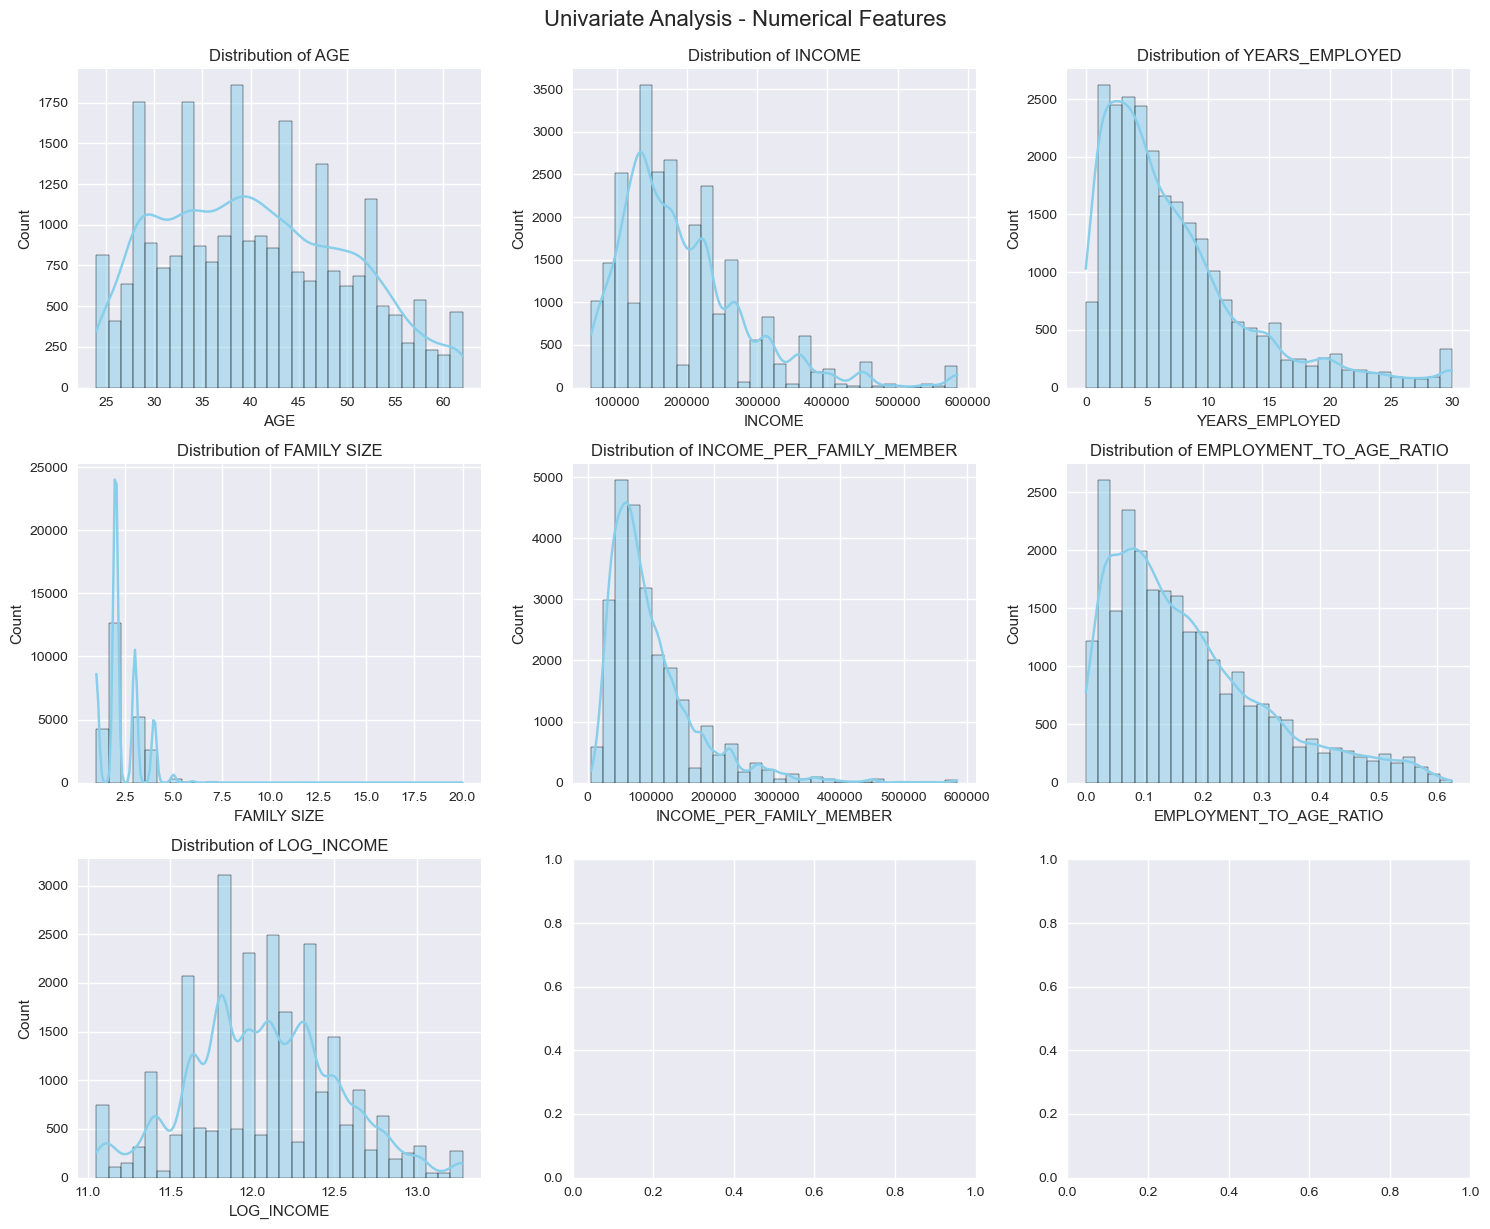

In [27]:
# Univariate Analysis - Numerical Features

numerical_cols = ['AGE', 'INCOME', 'YEARS_EMPLOYED', 'FAMILY SIZE', 
                  'INCOME_PER_FAMILY_MEMBER', 'EMPLOYMENT_TO_AGE_RATIO', 'LOG_INCOME']

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.ravel()

for i, col in enumerate(numerical_cols):
    if col in df.columns:
        sns.histplot(data=df, x=col, kde=True, ax=axes[i], bins=30, color='skyblue')
        axes[i].set_title(f'Distribution of {col}', fontsize=12)
        axes[i].set_xlabel(col)

plt.tight_layout()
plt.suptitle('Univariate Analysis - Numerical Features', y=1.02, fontsize=16)
plt.show()

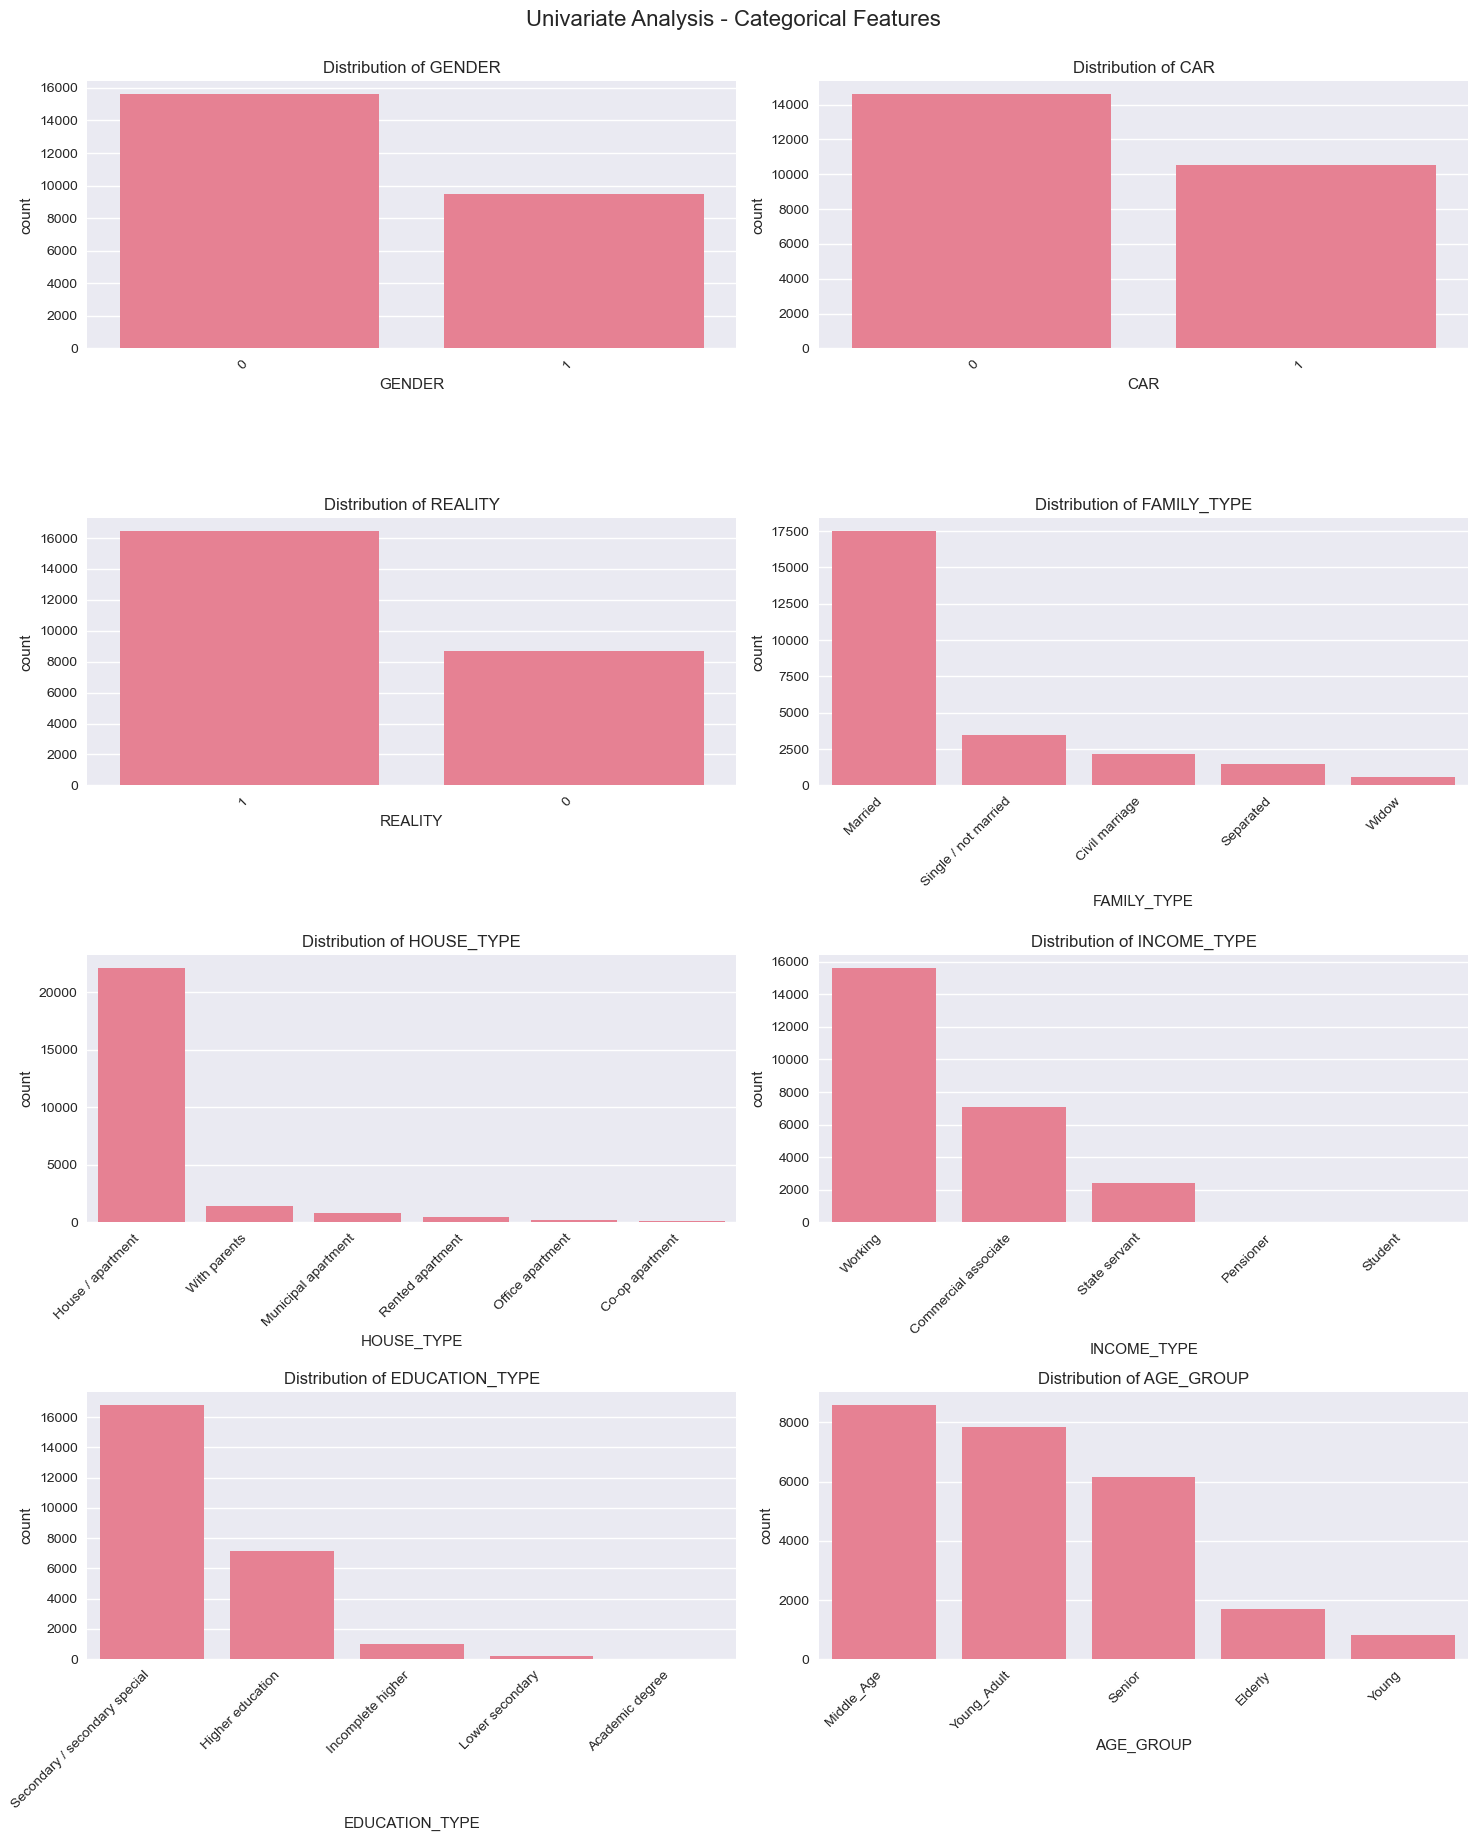

In [28]:
# Univariate Analysis - Categorical Features

categorical_cols = ['GENDER', 'CAR', 'REALITY', 'FAMILY_TYPE', 'HOUSE_TYPE', 
                    'INCOME_TYPE', 'EDUCATION_TYPE', 'AGE_GROUP']

fig, axes = plt.subplots(4, 2, figsize=(15, 18))
axes = axes.ravel()

for i, col in enumerate(categorical_cols):
    if col in df.columns:
        sns.countplot(data=df, x=col, ax=axes[i], order=df[col].value_counts().index)
        axes[i].set_title(f'Distribution of {col}', fontsize=12)
        axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.suptitle('Univariate Analysis - Categorical Features', y=1.02, fontsize=16)
plt.show()

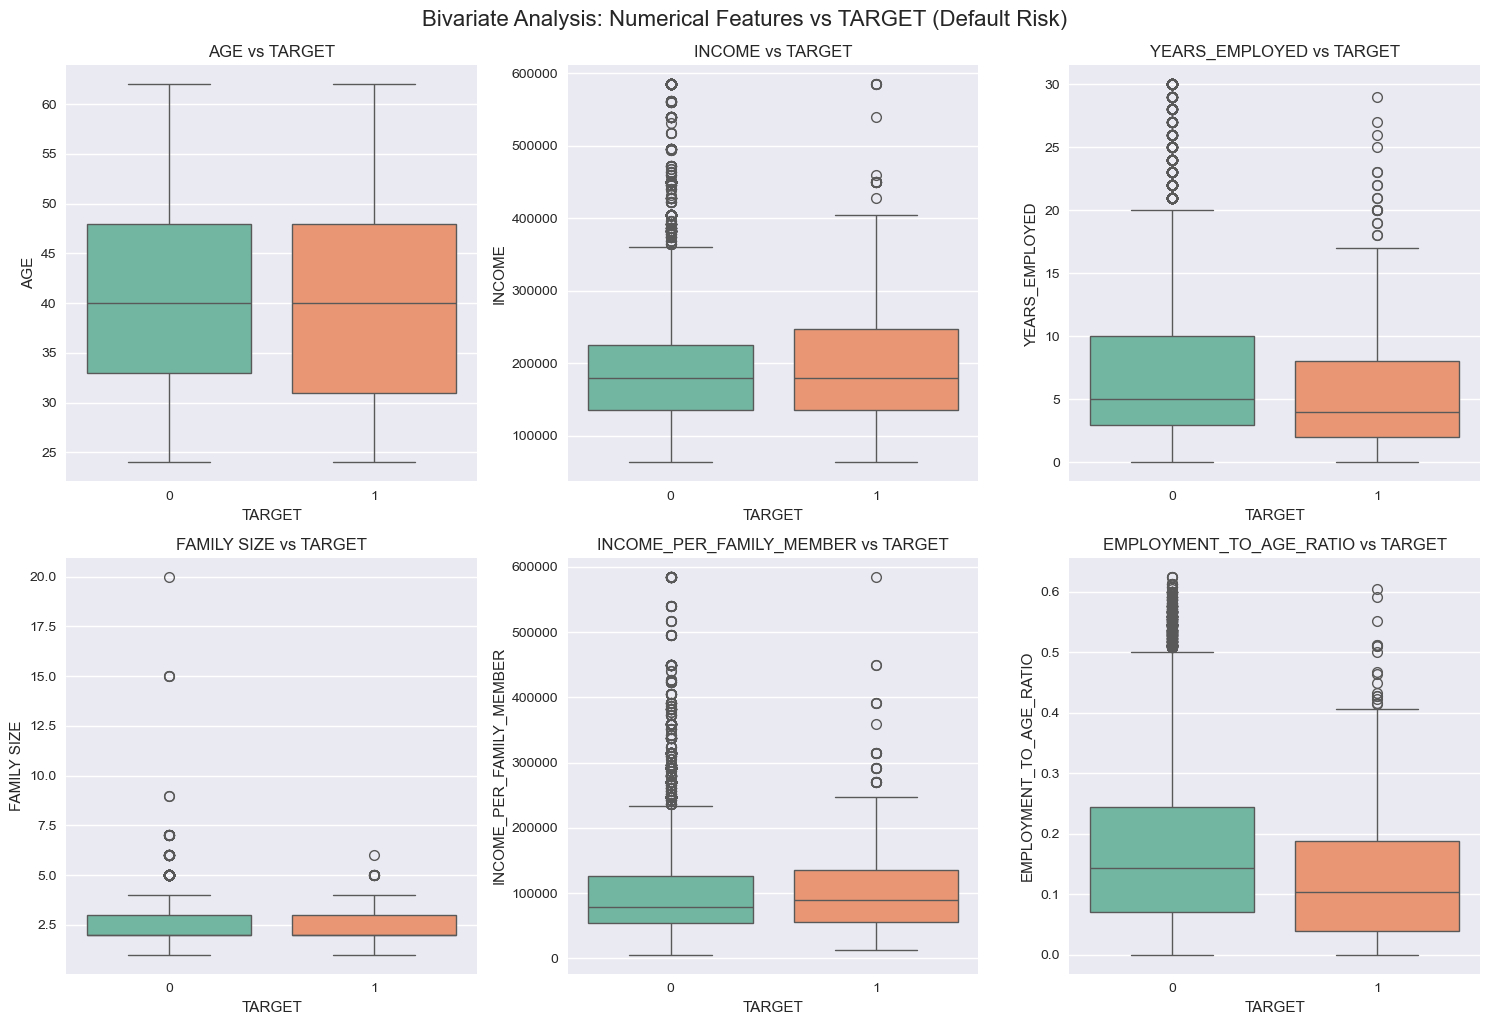

In [29]:
# Bivariate Analysis - Numerical vs TARGET

key_num = ['AGE', 'INCOME', 'YEARS_EMPLOYED', 'FAMILY SIZE', 
           'INCOME_PER_FAMILY_MEMBER', 'EMPLOYMENT_TO_AGE_RATIO']

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()

for i, col in enumerate(key_num):
    if col in df.columns:
        sns.boxplot(data=df, x='TARGET', y=col, ax=axes[i], palette="Set2")
        axes[i].set_title(f'{col} vs TARGET', fontsize=12)

plt.tight_layout()
plt.suptitle('Bivariate Analysis: Numerical Features vs TARGET (Default Risk)', y=1.02, fontsize=16)
plt.show()

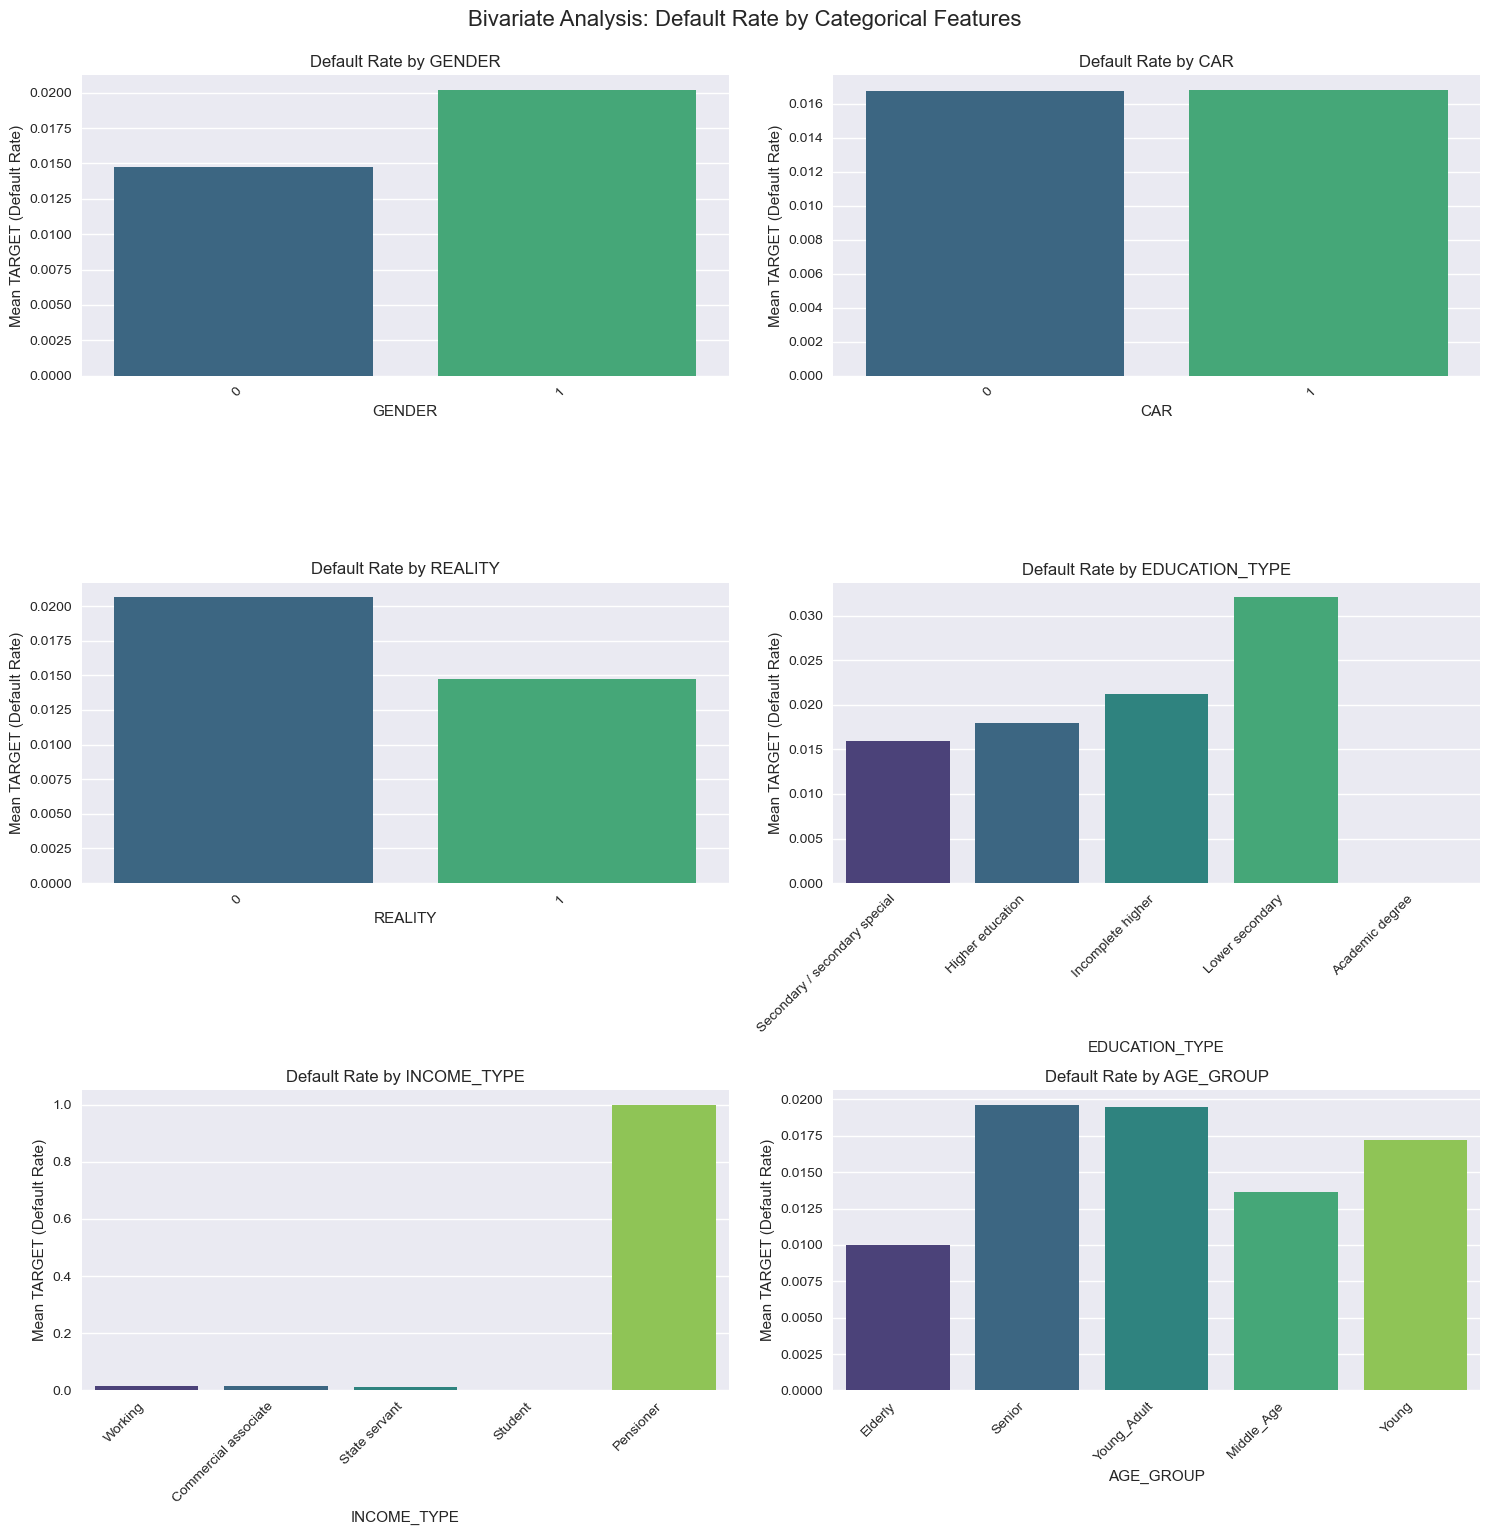

In [30]:
# Bivariate Analysis - Categorical vs TARGET

key_cat = ['GENDER', 'CAR', 'REALITY', 'EDUCATION_TYPE', 'INCOME_TYPE', 'AGE_GROUP']

fig, axes = plt.subplots(3, 2, figsize=(15, 15))
axes = axes.ravel()

for i, col in enumerate(key_cat):
    if col in df.columns:
        sns.barplot(data=df, x=col, y='TARGET', ax=axes[i], estimator=np.mean, errorbar=None, palette="viridis")
        axes[i].set_title(f'Default Rate by {col}', fontsize=12)
        axes[i].set_ylabel('Mean TARGET (Default Rate)')
        axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.suptitle('Bivariate Analysis: Default Rate by Categorical Features', y=1.02, fontsize=16)
plt.show()

Top Features Correlated with TARGET
TARGET                      1.0000
BEGIN_MONTH                 0.0607
GENDER                      0.0207
ID                          0.0206
INCOME_PER_FAMILY_MEMBER    0.0114
IS_SINGLE                   0.0102
INCOME                      0.0081
LOG_INCOME                  0.0081
WORK_PHONE                  0.0059
PHONE                       0.0031
E_MAIL                      0.0006
CAR                         0.0003
NO_OF_CHILD                -0.0009
HAS_CHILD                  -0.0038
FAMILY SIZE                -0.0056
AGE                        -0.0078
REALITY                    -0.0218
YEARS_EMPLOYED             -0.0345
EMPLOYMENT_TO_AGE_RATIO    -0.0358
FLAG_MOBIL                     NaN
Name: TARGET, dtype: float64

Highly Correlated Feature Pairs (Absolute Correlation > 0.7)
         Feature1                 Feature2  Correlation
4          INCOME               LOG_INCOME       0.9539
3  YEARS_EMPLOYED  EMPLOYMENT_TO_AGE_RATIO       0.9511
0    

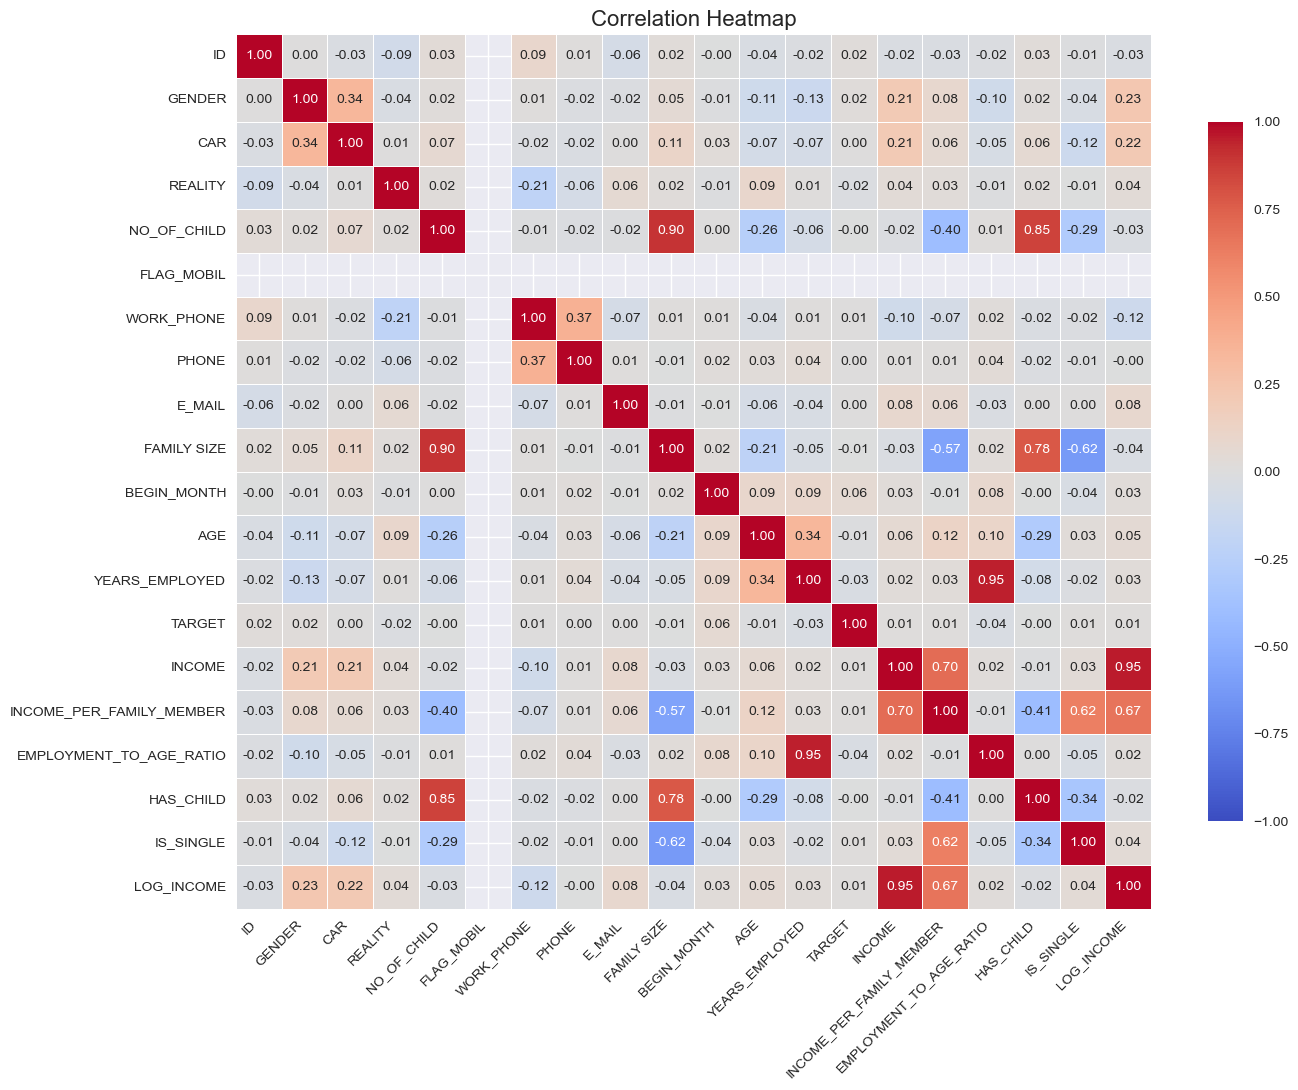


RECOMMENDATION for Feature Selection
Highly correlated pairs detected. Consider dropping one from each pair before modeling:
   → Drop either 'NO_OF_CHILD' or 'FAMILY SIZE' (corr = 0.902)
   → Drop either 'NO_OF_CHILD' or 'HAS_CHILD' (corr = 0.854)
   → Drop either 'FAMILY SIZE' or 'HAS_CHILD' (corr = 0.778)
   → Drop either 'YEARS_EMPLOYED' or 'EMPLOYMENT_TO_AGE_RATIO' (corr = 0.951)
   → Drop either 'INCOME' or 'LOG_INCOME' (corr = 0.954)


In [31]:
# Multivariate Analysis - Correlation Heatmap

# Automatic Correlation Analysis & Highly Correlated Columns
# Select only numerical columns
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()

# Compute correlation matrix
corr_matrix = df[num_cols].corr()

# Correlation with TARGET
print("Top Features Correlated with TARGET")
target_corr = corr_matrix['TARGET'].sort_values(ascending=False)
print(target_corr.round(4))

# Find Highly Correlated Feature Pairs
print("\nHighly Correlated Feature Pairs (Absolute Correlation > 0.7)")

# Create a mask to find upper triangle (avoid duplicate pairs)
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Find pairs with high correlation
high_corr_pairs = []
for i in range(len(upper_tri.columns)):
    for j in range(i+1, len(upper_tri.columns)):
        corr_value = upper_tri.iloc[i, j]
        if abs(corr_value) > 0.7:   # Change threshold as needed (0.7 is common)
            high_corr_pairs.append({
                'Feature1': upper_tri.columns[i],
                'Feature2': upper_tri.columns[j],
                'Correlation': corr_value
            })

high_corr_df = pd.DataFrame(high_corr_pairs)
if not high_corr_df.empty:
    print(high_corr_df.sort_values(by='Correlation', ascending=False).round(4))
else:
    print("No highly correlated pairs found above threshold 0.7")

# Correlation Heatmap
plt.figure(figsize=(14, 11))
sns.heatmap(corr_matrix, 
            annot=True, 
            cmap='coolwarm', 
            fmt='.2f', 
            linewidths=0.5,
            cbar_kws={'shrink': 0.8},
            vmin=-1, vmax=1)

plt.title('Correlation Heatmap', fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Recommendation for Multicollinearity 
print("\nRECOMMENDATION for Feature Selection")
if not high_corr_df.empty:
    print("Highly correlated pairs detected. Consider dropping one from each pair before modeling:")
    for _, row in high_corr_df.iterrows():
        print(f"   → Drop either '{row['Feature1']}' or '{row['Feature2']}' (corr = {row['Correlation']:.3f})")
else:
    print("No severe multicollinearity detected.")

In [32]:
#importing libries

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score, 
    precision_score, 
    recall_score, 
    f1_score, 
    classification_report,
    confusion_matrix
)
import matplotlib.pyplot as plt
import seaborn as sns

In [33]:
# Load the preprocessed dataset

df = pd.read_csv('Preprocessed_Credit_Card_Dataset.csv')
print(f"Dataset loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")
print("TARGET distribution:\n", df['TARGET'].value_counts(normalize=True).round(4)*100)

Dataset loaded: 25,122 rows × 25 columns
TARGET distribution:
 TARGET
0    98.32
1     1.68
Name: proportion, dtype: float64


In [34]:
# Define Features & Target

target = 'TARGET'
X = df.drop(columns=[target, 'ID'])          # Drop ID (not a feature)
y = df[target]

print(f"Features used: {X.shape[1]} columns")

Features used: 23 columns


In [35]:
# MODEL BUILDING WITH 70-20-10 SPLIT


# Split into Train (70%) + Temp (30%)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Split Temp into Test (20%) + GUI (10%)
X_test, X_gui, y_test, y_gui = train_test_split(
    X_temp, y_temp, test_size=1/3, random_state=42, stratify=y_temp
)

print(f"Train Set     : {X_train.shape[0]:,} rows ({X_train.shape[0]/len(df)*100:.1f}%)")
print(f"Test Set      : {X_test.shape[0]:,} rows ({X_test.shape[0]/len(df)*100:.1f}%)")
print(f"GUI Test Set  : {X_gui.shape[0]:,} rows ({X_gui.shape[0]/len(df)*100:.1f}%)")

Train Set     : 17,585 rows (70.0%)
Test Set      : 5,024 rows (20.0%)
GUI Test Set  : 2,513 rows (10.0%)


In [36]:
# Preprocessing Pipeline 
num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), cat_cols)
    ],
    remainder='passthrough'
)

In [37]:
# MODEL 1 - Logistic Regression 


lr_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(
        class_weight='balanced', 
        random_state=42, 
        max_iter=1000
    ))
])

# Train the model
lr_pipeline.fit(X_train, y_train)

# Make predictions
y_pred_lr = lr_pipeline.predict(X_test)
y_proba_lr = lr_pipeline.predict_proba(X_test)[:, 1] 

# ====================== EVALUATION METRICS ======================

print("LOGISTIC REGRESSION MODEL EVALUATION")
print("="*60)


accuracy = accuracy_score(y_test, y_pred_lr)
precision = precision_score(y_test, y_pred_lr, average='binary')      
recall = recall_score(y_test, y_pred_lr, average='binary')
f1 = f1_score(y_test, y_pred_lr, average='binary')

print(f"Accuracy   : {accuracy:.4f} ({accuracy*100:.3f}%)")
print(f"Precision  : {precision:.4f}")
print(f"Recall     : {recall:.4f}")
print(f"F1-Score   : {f1:.4f}")

# Classification Report
print("\nDETAILED CLASSIFICATION REPORT")
print("="*40)
print(classification_report(y_test, y_pred_lr, digits=4, 
                           target_names=['Non-Fraud (0)', 'Fraud (1)']))

# Confusion Matrix
print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred_lr)
cm_df = pd.DataFrame(cm, 
                     index=['Actual Non-Fraud', 'Actual Fraud'],
                     columns=['Predicted Non-Fraud', 'Predicted Fraud'])
print(cm_df)


LOGISTIC REGRESSION MODEL EVALUATION
Accuracy   : 0.6525 (65.247%)
Precision  : 0.0300
Recall     : 0.6235
F1-Score   : 0.0572

DETAILED CLASSIFICATION REPORT
               precision    recall  f1-score   support

Non-Fraud (0)     0.9902    0.6530    0.7870      4939
    Fraud (1)     0.0300    0.6235    0.0572        85

     accuracy                         0.6525      5024
    macro avg     0.5101    0.6382    0.4221      5024
 weighted avg     0.9739    0.6525    0.7746      5024


Confusion Matrix:
                  Predicted Non-Fraud  Predicted Fraud
Actual Non-Fraud                 3225             1714
Actual Fraud                       32               53


In [41]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.model_selection import RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
import time

print("Starting Fast Hyperparameter Tuning for Logistic Regression...")

# Use existing preprocessor
lr_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(
        class_weight='balanced',
        random_state=42,
        max_iter=1000,
        solver='liblinear'        
    ))
])

param_dist = {
    'classifier__C': [0.01, 0.1, 1, 10, 50],    
    'classifier__penalty': ['l1', 'l2']
}

start = time.time()

random_search = RandomizedSearchCV(
    estimator=lr_pipeline,
    param_distributions=param_dist,
    n_iter=8,                   
    cv=3,                        
    scoring='accuracy',               
    n_jobs=-1,
    verbose=1,
    random_state=42
)

random_search.fit(X_train, y_train)

print(f"Tuning finished in {time.time() - start:.1f} seconds")
print("Best Parameters:", random_search.best_params_)
print(f"Best CV F1-Score: {random_search.best_score_:.4f}")

# ====================== BEST MODEL EVALUATION ======================
best_lr = random_search.best_estimator_

y_pred_lr = best_lr.predict(X_test)
y_proba_lr = best_lr.predict_proba(X_test)[:, 1]

print("\nTUNED LOGISTIC REGRESSION EVALUATION")
print("="*70)

print(f"Accuracy   : {accuracy_score(y_test, y_pred_lr):.5f} ({accuracy_score(y_test, y_pred_lr)*100:.3f}%)")
print(f"Precision  : {precision_score(y_test, y_pred_lr):.5f}")
print(f"Recall     : {recall_score(y_test, y_pred_lr):.5f}")
print(f"F1-Score   : {f1_score(y_test, y_pred_lr):.5f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr, digits=4, 
                           target_names=['Non-Fraud (0)', 'Fraud (1)']))

print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred_lr)
print(pd.DataFrame(cm, 
                   index=['Actual Non-Fraud', 'Actual Fraud'],
                   columns=['Predicted Non-Fraud', 'Predicted Fraud']))

Starting Fast Hyperparameter Tuning for Logistic Regression...
Fitting 3 folds for each of 8 candidates, totalling 24 fits
Tuning finished in 401.8 seconds
Best Parameters: {'classifier__penalty': 'l1', 'classifier__C': 50}
Best CV F1-Score: 0.6519

TUNED LOGISTIC REGRESSION EVALUATION
Accuracy   : 0.65187 (65.187%)
Precision  : 0.02994
Recall     : 0.62353
F1-Score   : 0.05714

Classification Report:
               precision    recall  f1-score   support

Non-Fraud (0)     0.9902    0.6524    0.7865      4939
    Fraud (1)     0.0299    0.6235    0.0571        85

     accuracy                         0.6519      5024
    macro avg     0.5101    0.6379    0.4218      5024
 weighted avg     0.9739    0.6519    0.7742      5024


Confusion Matrix:
                  Predicted Non-Fraud  Predicted Fraud
Actual Non-Fraud                 3222             1717
Actual Fraud                       32               53


In [39]:
# MODEL 2 - XGBoost

xgb_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(
        n_estimators=400,
        max_depth=6,
        learning_rate=0.08,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=len(y_train[y_train==0])/len(y_train[y_train==1]),
        random_state=42,
        eval_metric='aucpr',
        tree_method='hist'       
    ))
])

# ====================== TRAIN & PREDICT ======================
xgb_pipeline.fit(X_train, y_train)

y_pred_xgb = xgb_pipeline.predict(X_test)
y_proba_xgb = xgb_pipeline.predict_proba(X_test)[:, 1]

# ====================== EVALUATION METRICS ======================
print("XGBoost MODEL EVALUATION")
print("="*70)

# Basic Metrics
accuracy = accuracy_score(y_test, y_pred_xgb)
precision = precision_score(y_test, y_pred_xgb, average='binary')
recall = recall_score(y_test, y_pred_xgb, average='binary')
f1 = f1_score(y_test, y_pred_xgb, average='binary')

print(f"Accuracy   : {accuracy:.4f} ({accuracy*100:.3f}%)")
print(f"Precision  : {precision:.4f}")
print(f"Recall     : {recall:.4f}")
print(f"F1-Score   : {f1:.4f}")

# Detailed Report
print("\nDETAILED CLASSIFICATION REPORT")
print("="*50)
print(classification_report(y_test, y_pred_xgb, digits=4,
                           target_names=['Non-Fraud (0)', 'Fraud (1)']))

# Confusion Matrix
print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred_xgb)
cm_df = pd.DataFrame(cm,
                     index=['Actual Non-Fraud', 'Actual Fraud'],
                     columns=['Predicted Non-Fraud', 'Predicted Fraud'])
print(cm_df)

XGBoost MODEL EVALUATION
Accuracy   : 0.9753 (97.532%)
Precision  : 0.3069
Recall     : 0.3647
F1-Score   : 0.3333

DETAILED CLASSIFICATION REPORT
               precision    recall  f1-score   support

Non-Fraud (0)     0.9890    0.9858    0.9874      4939
    Fraud (1)     0.3069    0.3647    0.3333        85

     accuracy                         0.9753      5024
    macro avg     0.6480    0.6753    0.6604      5024
 weighted avg     0.9775    0.9753    0.9764      5024


Confusion Matrix:
                  Predicted Non-Fraud  Predicted Fraud
Actual Non-Fraud                 4869               70
Actual Fraud                       54               31


In [42]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform, randint

xgb_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(
        random_state=42,
        eval_metric='auc',
        tree_method='hist'          
    ))
])

param_dist = {
    'classifier__n_estimators': randint(150, 500),
    'classifier__max_depth': randint(3, 8),
    'classifier__learning_rate': uniform(0.05, 0.15),
    'classifier__subsample': uniform(0.7, 0.3),
    'classifier__colsample_bytree': uniform(0.7, 0.3),
    'classifier__gamma': [0, 0.1, 0.2],
    'classifier__scale_pos_weight': [1, 5, 10, 20]   
}

# ====================== RANDOMIZED SEARCH ======================
start = time.time()

random_search = RandomizedSearchCV(
    estimator=xgb_pipeline,
    param_distributions=param_dist,
    n_iter=15,                   
    cv=3,
    scoring='accuracy',          
    n_jobs=-1,
    verbose=1,
    random_state=42
)

random_search.fit(X_train, y_train)

print(f"\nTuning Completed in {time.time() - start:.1f} seconds")
print("Best Parameters:", random_search.best_params_)
print(f"Best Cross-Validation Accuracy: {random_search.best_score_:.5f}")

# ====================== BEST MODEL EVALUATION ======================
best_xgb = random_search.best_estimator_

y_pred_xgb = best_xgb.predict(X_test)
y_proba_xgb = best_xgb.predict_proba(X_test)[:, 1]


print("\nTUNED XGBoost EVALUATION - OPTIMIZED FOR ACCURACY")
print("="*80)

print(f"Accuracy   : {accuracy_score(y_test, y_pred_xgb):.5f} ({accuracy_score(y_test, y_pred_xgb)*100:.3f}%)")
print(f"Precision  : {precision_score(y_test, y_pred_xgb):.5f}")
print(f"Recall     : {recall_score(y_test, y_pred_xgb):.5f}")
print(f"F1-Score   : {f1_score(y_test, y_pred_xgb):.5f}")

print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred_xgb, digits=4, 
                           target_names=['Non-Fraud (0)', 'Fraud (1)']))

print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred_xgb)
print(pd.DataFrame(cm, 
                   index=['Actual Non-Fraud', 'Actual Fraud'],
                   columns=['Predicted Non-Fraud', 'Predicted Fraud']))

Fitting 3 folds for each of 15 candidates, totalling 45 fits

Tuning Completed in 35.6 seconds
Best Parameters: {'classifier__colsample_bytree': np.float64(0.7265477506155757), 'classifier__gamma': 0.2, 'classifier__learning_rate': np.float64(0.12812513900387357), 'classifier__max_depth': 7, 'classifier__n_estimators': 357, 'classifier__scale_pos_weight': 1, 'classifier__subsample': np.float64(0.7814047095321688)}
Best Cross-Validation Accuracy: 0.98374

TUNED XGBoost EVALUATION - OPTIMIZED FOR ACCURACY
Accuracy   : 0.98169 (98.169%)
Precision  : 0.40000
Recall     : 0.16471
F1-Score   : 0.23333

Detailed Classification Report:
               precision    recall  f1-score   support

Non-Fraud (0)     0.9858    0.9957    0.9907      4939
    Fraud (1)     0.4000    0.1647    0.2333        85

     accuracy                         0.9817      5024
    macro avg     0.6929    0.5802    0.6120      5024
 weighted avg     0.9759    0.9817    0.9779      5024


Confusion Matrix:
            

In [43]:
# Save GUI Test Data Set
pd.concat([X_gui, y_gui], axis=1).to_csv('GUI_Test_Data_Set.csv', index=False)
print("GUI Test Data Set saved successfully!")

GUI Test Data Set saved successfully!


In [46]:
import joblib

# Save models with .pkl extension
joblib.dump(best_xgb, 'xgboost_model.pkl')
joblib.dump(best_lr, "logistic_regression_model.pkl")

print("Models successfully saved with .pkl extension!")

Models successfully saved with .pkl extension!
